In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

In [ ]:
ds, info = tfds.load('malaria', split='train', shuffle_files=True, with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/27558 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/1.0.0.incompleteH7IH3P/malaria-train.tfrecord*...:   0%|          …

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.


In [ ]:
def preprocess(features):
    image = tf.image.resize(features['image'], (70, 70))
    image = tf.cast(image, tf.float32) / 255.0
    label = features['label']
    return image, label

ds = ds.map(preprocess)

In [ ]:
train_size = int(0.8 * info.splits['train'].num_examples)
train_ds = ds.take(train_size)
val_ds = ds.skip(train_size)

In [ ]:
train_ds = train_ds.shuffle(1024).batch(64)
val_ds = val_ds.batch(64)


In [ ]:
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import GridSearchCV
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import glob
import os
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
def create_model(optimizer='adam', dropout_rate=0.3, units=256, learning_rate=0.001, activation='relu'):
    if optimizer == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

    input_layer = Input(shape=(70, 70, 3))
    x = Conv2D(64, 3, activation=activation, padding="same")(input_layer)
    x = MaxPooling2D((2, 2), strides=2)(x)
    x = Conv2D(128, 3, padding="same", activation=activation)(x)
    x = MaxPooling2D((2, 2), strides=2)(x)
    x = Flatten()(x)
    x = Dense(units, activation=activation)(x)
    x = Dropout(dropout_rate)(x)
    output_layer = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [ ]:
optimizers = ['adam', 'sgd']
dropout_rates = [0.2, 0.3, 0.4]
units_list = [128, 256, 512]
learning_rates = [0.001, 0.01]
activations = ['relu', 'tanh']

In [ ]:
results = []
best_score = 0
best_params = {}

for optimizer in optimizers:
    for dropout_rate in dropout_rates:
        for units in units_list:
            for learning_rate in learning_rates:
                for activation in activations:
                    model = create_model(optimizer, dropout_rate, units, learning_rate, activation)
                    model.fit(train_ds, epochs=5, validation_data=val_ds, verbose=0)
                    _, accuracy = model.evaluate(val_ds, verbose=0)
                    results.append((optimizer, dropout_rate, units, learning_rate, activation, accuracy))
                    if accuracy > best_score:
                        best_score = accuracy
                        best_params = {'optimizer': optimizer, 'dropout_rate': dropout_rate,
                                       'units': units, 'learning_rate': learning_rate, 'activation': activation}

print("Best Score:", best_score)
print("Best Params:", best_params)

Best Score: 0.9490203261375427
Best Params: {'optimizer': 'adam', 'dropout_rate': 0.2, 'units': 512, 'learning_rate': 0.001, 'activation': 'relu'}


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results, columns=['Optimizer', 'Dropout Rate', 'Units', 'Learning Rate', 'Activation', 'Accuracy'])


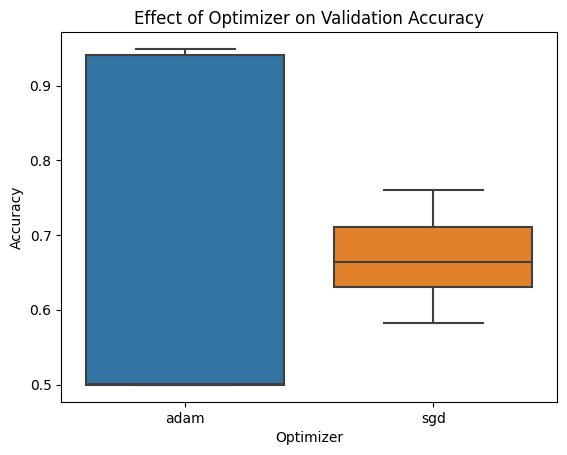

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Optimizer', y='Accuracy', data=results_df)
plt.title('Effect of Optimizer on Validation Accuracy')
plt.show()

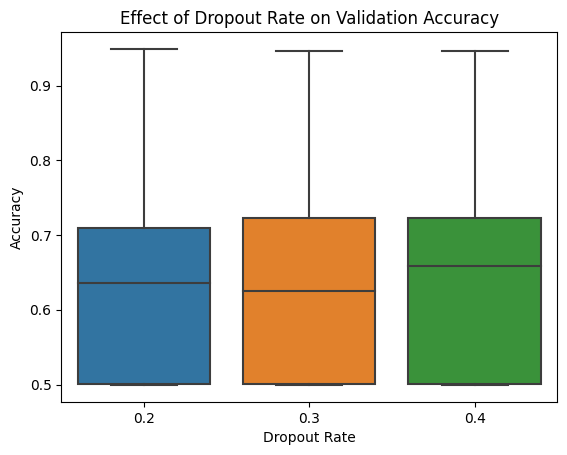

In [ ]:
sns.boxplot(x='Dropout Rate', y='Accuracy', data=results_df)
plt.title('Effect of Dropout Rate on Validation Accuracy')
plt.show()


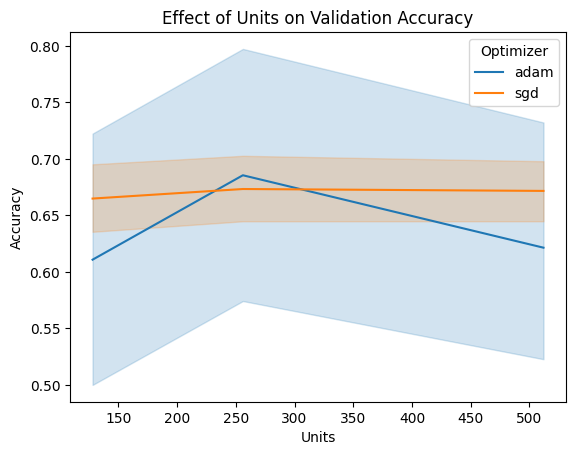

In [ ]:
sns.lineplot(x='Units', y='Accuracy', hue='Optimizer', data=results_df)
plt.title('Effect of Units on Validation Accuracy')
plt.show()


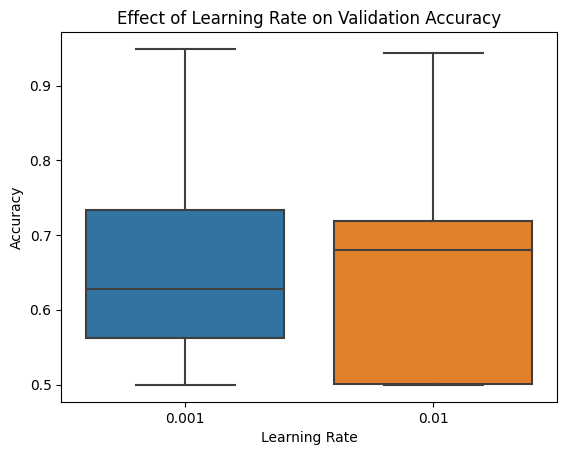

In [ ]:
sns.boxplot(x='Learning Rate', y='Accuracy', data=results_df)
plt.title('Effect of Learning Rate on Validation Accuracy')
plt.show()


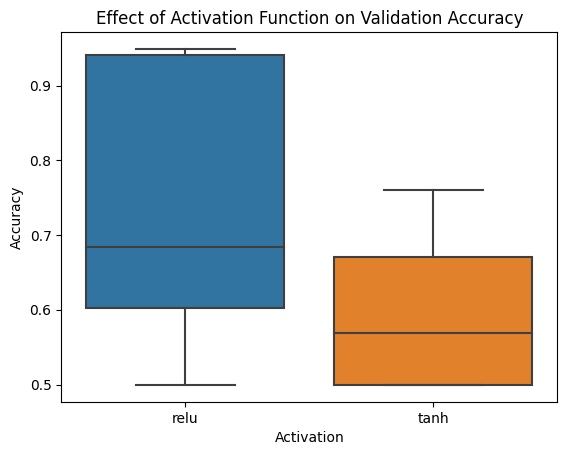

In [ ]:
sns.boxplot(x='Activation', y='Accuracy', data=results_df)
plt.title('Effect of Activation Function on Validation Accuracy')
plt.show()


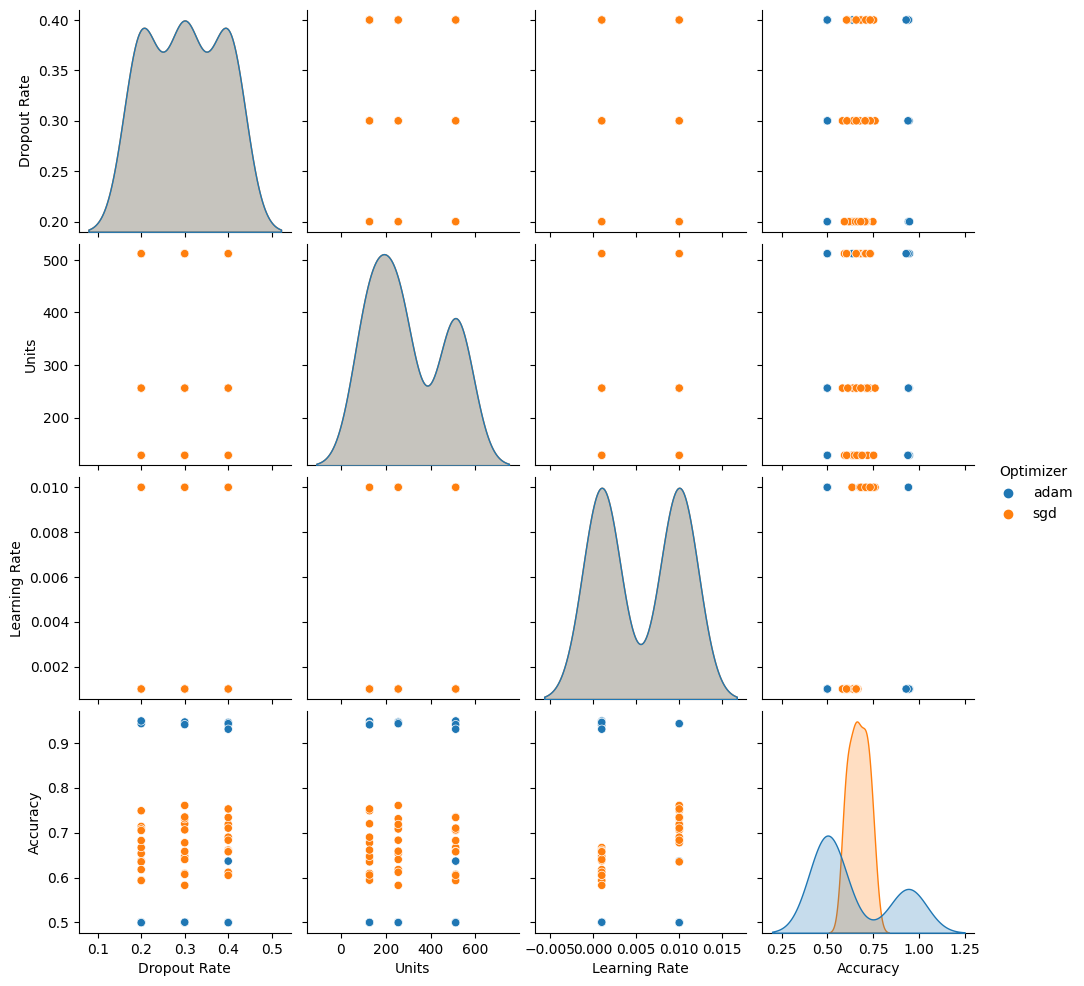

In [ ]:
sns.pairplot(results_df, hue="Optimizer", diag_kind="kde")
plt.show()


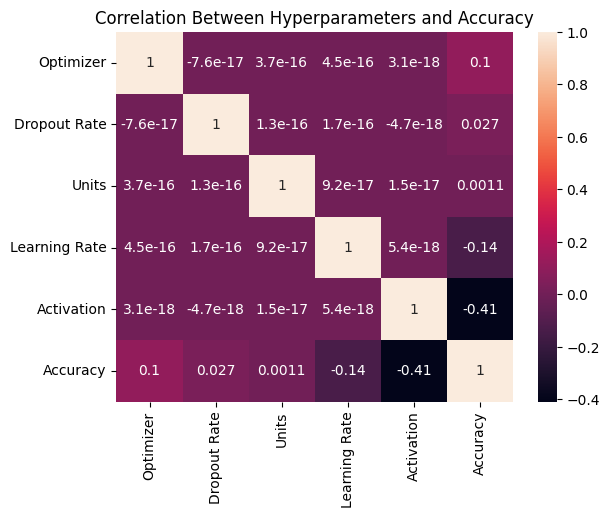

In [ ]:
correlation_df = results_df.copy()
correlation_df['Optimizer'] = correlation_df['Optimizer'].astype('category').cat.codes
correlation_df['Activation'] = correlation_df['Activation'].astype('category').cat.codes

correlation_matrix = correlation_df.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Between Hyperparameters and Accuracy')
plt.show()


In [ ]:
# Importing required libraries
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, ReLU, Add, GlobalAveragePooling2D, Dense

def residual_block(x, filters, kernel_size=3, stride=1, conv_shortcut=True):
    """
    A residual block for ResNet.
    """
    # Shortcut
    if conv_shortcut:
        shortcut = Conv2D(4 * filters, 1, strides=stride)(x)
        shortcut = BatchNormalization()(shortcut)
    else:
        shortcut = x

    # First convolution layer
    x = Conv2D(filters, 1, strides=stride)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Second convolution layer
    x = Conv2D(filters, kernel_size, padding="SAME")(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Third convolution layer
    x = Conv2D(4 * filters, 1)(x)
    x = BatchNormalization()(x)

    # Adding the shortcut to the output
    x = Add()([shortcut, x])
    x = ReLU()(x)

    return x

# Improved ResNet-50 architecture
def Improved_ResNet50(input_shape=(70, 70, 3)):
    """
    Build an improved version of ResNet-50.
    """
    input_layer = Input(shape=input_shape)

    # Initial Conv Layer
    x = Conv2D(64, (7, 7), strides=(2, 2), padding="same")(input_layer)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Residual Blocks
    x = residual_block(x, 64, stride=1, conv_shortcut=True)  # First block with conv_shortcut
    x = residual_block(x, 64)
    x = residual_block(x, 64)

    x = residual_block(x, 128, stride=2, conv_shortcut=True)  # Increasing filters, conv_shortcut for downsampling
    x = residual_block(x, 128)
    x = residual_block(x, 128)
    x = residual_block(x, 128)

    x = residual_block(x, 256, stride=2, conv_shortcut=True)  # Increasing filters, conv_shortcut for downsampling
    x = residual_block(x, 256)
    x = residual_block(x, 256)
    x = residual_block(x, 256)
    x = residual_block(x, 256)
    x = residual_block(x, 256)

    x = residual_block(x, 512, stride=2, conv_shortcut=True)  # Increasing filters, conv_shortcut for downsampling
    x = residual_block(x, 512)
    x = residual_block(x, 512)

    # Global Average Pooling layer
    x = GlobalAveragePooling2D()(x)

    # Fully connected layer
    output_layer = Dense(1, activation='sigmoid')(x)

    # Create Model
    model = Model(inputs=input_layer, outputs=output_layer)

    return model

# Create the improved ResNet-50 model
improved_resnet50_model = Improved_ResNet50()

In [3]:
results = []
best_score = 0
best_params = {}

for optimizer in optimizers:
    for dropout_rate in dropout_rates:
        for learning_rate in learning_rates:
            for activation in activations:
                model = Improved_ResNet50()  # Function to create an Improved ResNet-50 model
                # Set the optimizer, learning rate, and other hyperparameters
                model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

                # Train the model
                model.fit(train_ds, epochs=5, validation_data=val_ds, verbose=0)

                # Evaluate the model
                _, accuracy = model.evaluate(val_ds, verbose=0)

                results.append((optimizer, dropout_rate, learning_rate, activation, accuracy))

                if accuracy > best_score:
                    best_score = accuracy
                    best_params = {'optimizer': optimizer, 'dropout_rate': dropout_rate,
                                   'learning_rate': learning_rate, 'activation': activation}


Best Score: 0.9742420563355917
Best Params: {'optimizer': 'adam', 'dropout_rate': 0.2, 'units': 512, 'learning_rate': 0.001, 'activation': 'relu'}
